# Imitacija grafika po slici
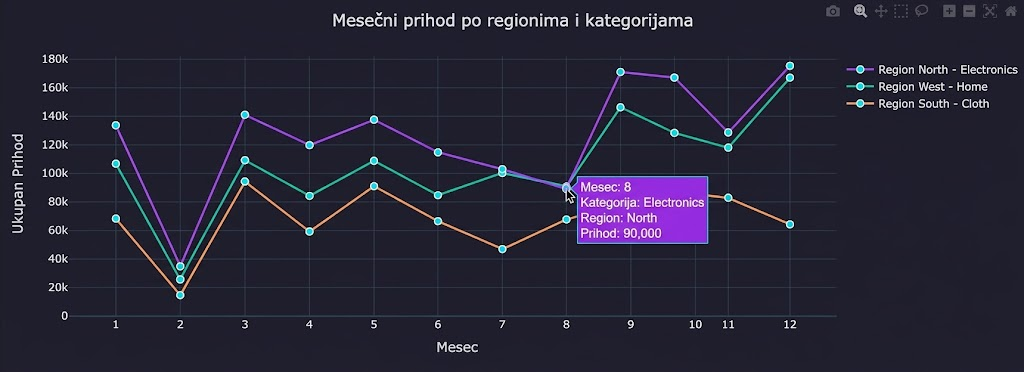

## Import i imfo

In [751]:
import pandas as pd
import numpy as np
import plotly.express as px

df = pd.read_csv("D:/Python/libraries/prodaja_mesec_region_raw.csv")

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 380 entries, 0 to 379
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   mesec       353 non-null    object
 1   kategorija  321 non-null    object
 2   region      340 non-null    object
 3   prihod      347 non-null    object
dtypes: object(4)
memory usage: 12.0+ KB


## Analiza i ciscenje CSV-a

#### Sve kolone

In [752]:
print(df.duplicated().sum()) # 31 duplikat
df.drop_duplicates(keep="first", inplace=True)

print(df.isna().sum()) # od 26 do 53 nepostojecih vrednosti po koloni
df.dropna(axis=0, inplace=True)
print(df.isna().sum())

df.reset_index(drop=True, inplace=True)

31
mesec         26
kategorija    53
region        36
prihod        31
dtype: int64
mesec         0
kategorija    0
region        0
prihod        0
dtype: int64


#### Kolona Mesec

In [753]:
print(df["mesec"].value_counts()) # Imamo kolonu "03" i kolonu "Mesec 5" koje treba da promenimo

mesec_mapping = {
    "03" : 3,
    "Mesec 5" : 5
}

df["mesec"] = df["mesec"].replace(mesec_mapping)
df["mesec"] = pd.to_numeric(df["mesec"], errors="coerce") # Pretvaranje u brojeve
df["mesec"] = df["mesec"].astype("Int8") # Int8 radi cuvanja memorije (nepotreban Int64 kad brojevi idu do 12)

mesec
12         32
7          18
8          18
10         18
2          17
9          17
1          16
4          16
03         15
5          14
Mesec 5    13
6          13
11         12
Name: count, dtype: int64


#### Kolona Kategorija

In [754]:
print(df["kategorija"].value_counts()) # vrednost " electronic" ima razmak, ostale vrednosti se ponavljaju u verzijama sa malim ili velikim slovima
df["kategorija"] = df["kategorija"].str.strip().str.upper()
df["kategorija"] = df["kategorija"].astype("category")

kategorija
Cloth           39
 electronics    36
ELECTRONICS     31
home            31
Electronics     30
Home            29
CLOTH           23
Name: count, dtype: int64


#### Kolona Region

In [755]:
print(df["region"].value_counts()) # isti princip kao za kategoriju
df["region"] = df["region"].str.strip().str.upper()
df["region"] = df["region"].astype("category")

region
west      43
North     41
 north    28
West      27
SOUTH     27
NORTH     27
South     26
Name: count, dtype: int64


#### Kolona Prihod

In [756]:
print(df["prihod"].sample(n=10, random_state=42)) # Zarezi, simbol "$", tekst "RSD", razmaci...
df["prihod"] = df["prihod"].str.replace(",", "", regex=False).str.replace("$", "", regex=False).str.replace("RSD", "", regex=False).str.strip()

df["prihod"] = pd.to_numeric(df["prihod"], errors="coerce")
df["prihod"] = df["prihod"].astype("Int16")

154    14,316
93       6422
216     $6473
217      2526
15      $5266
104      5310
171     12301
208      5778
75      13641
141     6,107
Name: prihod, dtype: object


In [757]:
df.info() # Svi redovi su non-null, tipovi kolona definisani (nisu object) - memorija smanjena sa 12kb na 2kb - 83.33% smanjeno

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 219 entries, 0 to 218
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype   
---  ------      --------------  -----   
 0   mesec       219 non-null    Int8    
 1   kategorija  219 non-null    category
 2   region      219 non-null    category
 3   prihod      219 non-null    Int16   
dtypes: Int16(1), Int8(1), category(2)
memory usage: 1.9 KB


## Pravljenje pocetnog grafika

#### Grupisanje podataka - priprema dataframe-a

In [758]:
df["region_kategorija"] = df["region"].astype(str) + " - " + df["kategorija"].astype(str) # Grupisanje dve kolone u jednu

df_group = df.groupby(["mesec", "region_kategorija"], observed=True).agg(total = ("prihod", "sum")).reset_index()

df_mesecni_prihod = df_group[(df_group["region_kategorija"] == "NORTH - ELECTRONICS") | 
                             (df_group["region_kategorija"] == "WEST - HOME") |
                             (df_group["region_kategorija"] == "SOUTH - CLOTH")]

fig = px.line(df_mesecni_prihod,
              x = "mesec",
              y = "total",
              color = "region_kategorija",
              color_discrete_map={"NORTH - ELECTRONICS": "#C033F3", "WEST - HOME": "#38DCC8", "SOUTH - CLOTH": "#FFBF00"},
              markers="True",
              template = "plotly_dark")

fig.update_layout(title=dict(text="Mesecni prihod po regionima i kategorijama", font=dict(size=18), xanchor="center", x=0.5),
                  paper_bgcolor = "#1e1e2e",
                  plot_bgcolor = "#1e1e2e",
                  legend=dict(title=""),
                  hoverlabel=dict(
                        bgcolor="#A100FF",  # Ljubičasta pozadina tooltipa
                        font_color="white",  # Beli tekst
                        font_size=13,
                        bordercolor="cyan"))

fig.update_traces(hovertemplate = "Mesec: %{x}<br>Region - Kategorija: %{fullData.name}<br>Prihod: %{y:,.0f}<extra></extra>",
                  marker_color = "cyan",
                  marker_size = 7,
                  marker_line_color = "white",
                  marker_line_width = 1.5)

fig.update_xaxes(title="Mesec", dtick=1, range=[0.3, 12.7])
fig.update_yaxes(title="Ukupan Prihod")
fig.show()

## Refleksija

Na slici vidimo da su kategorija i region spojeni i da su po tome linije odvojeno, medjutim na hover-u vidimo da su dve odvojene vrednosti. Smatram da je odvajanje ovih vrednosti (koje su svakako nepromenjive za jednu liniju) nepotrebno i da je cak preglednost mozda i bolja ovako kako je uradjeno.

Ostatak grafika je dobar, nema negativnih aspekata, osim razlike u podacima i samim time razlika u izgledu linija - vidimo da niko sa zapada nije kupovao nista u "home" sekciji u novembru i decembru, isto vazi i za region juga - niko nije kupovao nista u "cloth" u tim mesecima.
